# A Quick Tour of Tensorflow

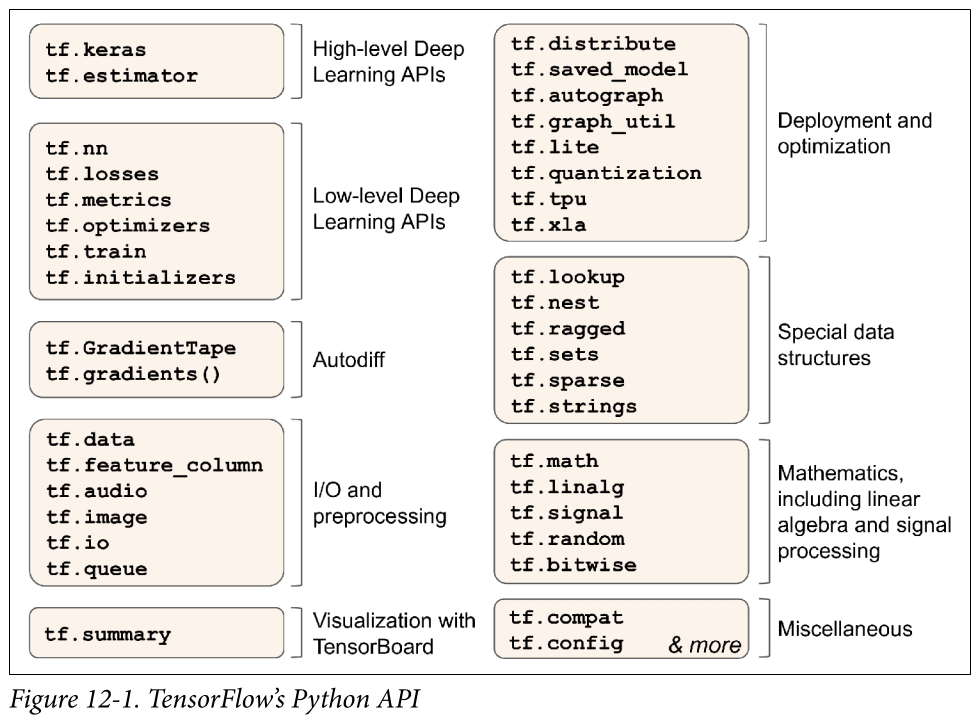

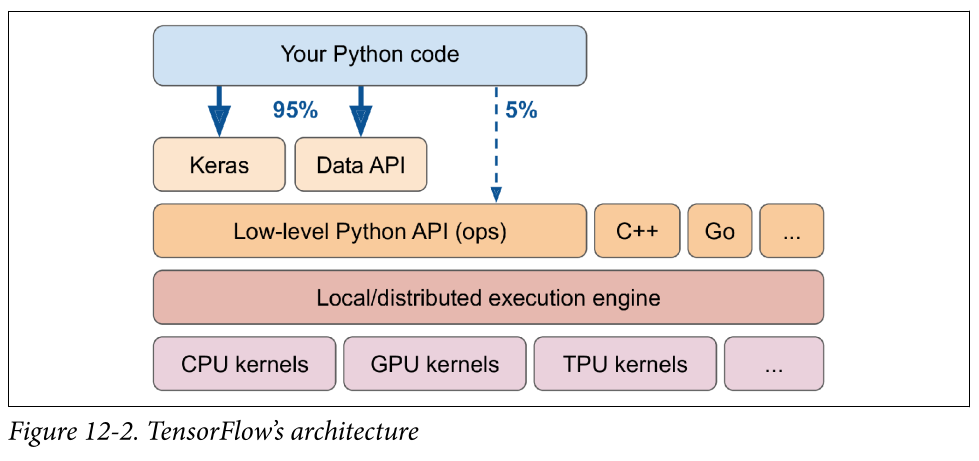

__Notes:__
* Each tensorflow operation (op) is implemented using c++. Many operations have multiple kernels, each kernel is dedicated to a specific device type such as GPUs and CPUs or even TPUs (tensor processing units). 
* Tensorflow runs on Windows, Linux, macOS, iOS, and Android, and you can write your code in Python, C++, Java, Go, Swift, and even JavaScript.

# Using Tensorflow like NumPy

## Tensors and Operations

In [2]:
# constants
import tensorflow as tf

#scaler
scaler = tf.constant(42)

#matrix
matrix = tf.constant([
    [1, 2, 3],
    [4, 5, 6]
], dtype = tf.float32)

In [8]:
#indexing works like numpy
matrix[:, 0]

<tf.Tensor: shape=(2,), dtype=float32, numpy=array([1., 4.], dtype=float32)>

In [9]:
#tensor operations
matrix += 10
matrix

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[11., 12., 13.],
       [14., 15., 16.]], dtype=float32)>

In [10]:
tf.square(matrix)

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[121., 144., 169.],
       [196., 225., 256.]], dtype=float32)>

In [12]:
matrix @ tf.transpose(matrix) # (@) stands for matrix multiplication

<tf.Tensor: shape=(2, 2), dtype=float32, numpy=
array([[434., 542.],
       [542., 677.]], dtype=float32)>

All the basic mathematical operations and tensor operations in numpy are also available in tensorflow! 

Keras also has its low-level API, but it only has a subset of the features available in the Tensorflow low-level API. If you want to write code that is portable to other keras implementations, you should use the keras API. 

## Tensors and Numpy

You can create tensors using numpy arrays, and you also create numpy arrays from tensors! You can even apply tensorflow operations or numpy operations to either tensors or numpy arrays!

In [16]:
import numpy as np
a = np.array([2, 4, 5], dtype = np.float32)

t = tf.constant(a)

In [17]:
t, a

(<tf.Tensor: shape=(3,), dtype=float32, numpy=array([2., 4., 5.], dtype=float32)>,
 array([2., 4., 5.], dtype=float32))

In [18]:
t.numpy()

array([2., 4., 5.], dtype=float32)

In [19]:
tf.square(a), np.square(t)

(<tf.Tensor: shape=(3,), dtype=float32, numpy=array([ 4., 16., 25.], dtype=float32)>,
 array([ 4., 16., 25.], dtype=float32))

__Note:__ Tensorflow uses 32-bit floats by default, while numpy uses 64-bit floats. This is because 32-bit floats have enough precision for neural networks, and they take less space and are faster to manipulate. Make sure to set dtype = tf.float32 when you create tensors from numpy arrays.

## Type conversions

Tensorflow does not do type conversion by default. This is because type conversions take time and hurt performance. Therefore, you cannot do operations on tensors of different types (e.g. integers and floats, float32 and float64, etc.).

In [20]:
tf.constant(2.) + tf.constant(40)

InvalidArgumentError: cannot compute AddV2 as input #1(zero-based) was expected to be a float tensor but is a int32 tensor [Op:AddV2] name: 

In [21]:
tf.constant(2.0) + tf.constant(40., dtype = tf.float64)

InvalidArgumentError: cannot compute AddV2 as input #1(zero-based) was expected to be a float tensor but is a double tensor [Op:AddV2] name: 

In [22]:
#You can use the tf.cast() function to convert types!
t2 = tf.constant(40.0, dtype = tf.float64)
tf.constant(2.0) + tf.cast(t2, tf.float32)

<tf.Tensor: shape=(), dtype=float32, numpy=42.0>

## Variables

All the constants we have used so far cannot be changed (are immutable). If we need to manipulate the values of them, we need a tf.Variable type. 

In [23]:
v = tf.Variable([
    [1, 2, 3],
    [4, 5, 6]
], dtype = tf.float32)


In [24]:
v

<tf.Variable 'Variable:0' shape=(2, 3) dtype=float32, numpy=
array([[1., 2., 3.],
       [4., 5., 6.]], dtype=float32)>

To assign values to the Variable, you need to use the .assign() method. 

In [29]:
v.assign(2 * v)

<tf.Variable 'UnreadVariable' shape=(2, 3) dtype=float32, numpy=
array([[ 6.,  4.,  6.],
       [ 8., 10., 12.]], dtype=float32)>

In [30]:
v[0, 1].assign(42)

<tf.Variable 'UnreadVariable' shape=(2, 3) dtype=float32, numpy=
array([[ 6., 42.,  6.],
       [ 8., 10., 12.]], dtype=float32)>

In [31]:
v[:, 2].assign([0.0, 1.0])

<tf.Variable 'UnreadVariable' shape=(2, 3) dtype=float32, numpy=
array([[ 6., 42.,  0.],
       [ 8., 10.,  1.]], dtype=float32)>

In [32]:
v.scatter_nd_update(indices = [[0,0], [1, 2]], updates = [100.0, 200.0])

<tf.Variable 'UnreadVariable' shape=(2, 3) dtype=float32, numpy=
array([[100.,  42.,   0.],
       [  8.,  10., 200.]], dtype=float32)>

## Other data Structures

1. Sparse tensors (tf.SparseTensor): efficiently represent tensors that contain mostly zeros.
2. Tensor arrays (tf.TensorArray): Are lists of tensors. They are fixed in size, but can be made dynamic. All the tensors they contain must be of the same shape and data type.
3. Ragged tensors (tf.RaggedTensor): Represent static lists of lists of tensors, where every tensor has the same shape and data type. 
4. String tensors: are tensors of type tf.string. These represent byte strings, not Unicode strings, so if you create a string tensor using Unicode string, it will get encoded to UTF-8 automatically. 
5. Sets: Are represented as regular tensors (or sparse tensors). For example, tf.constant([[1, 2], [3, 4]]) represents two sets ({1, 2}, {3, 4}). 
6. Queues: Store tensors across different steps. 

# Customizing Models and Training Algorithms

## Custom Loss Functions

You can create your own loss function by creating a functions that receives the predictions and labels and manipulates them using tf operations to calculate the final loss value as follows:

In [21]:
# Implementing huber loss
def huber_function(y_true, y_pred):
    error = y_true - y_pred
    is_small_error = tf.abs(error) < 1
    squared_loss = tf.square(error) / 2
    linear_loss = tf.abs(error) - 0.5
    return tf.where(is_small_error, squared_loss, linear_loss)

In [5]:
import keras
model = keras.models.Sequential([
    keras.layers.Input(shape = (100,)),
    keras.layers.Dense(100, activation = 'relu'),
    keras.layers.Dense(1, activation='sigmoid')

])
#using the custom loss in keras!
model.compile(
    optimizer = 'nadam',
    loss = huber_function,
)

## Saving and Loading Models that Contain Custom Components

Saving a model that contains a custom loss function work fine, as keras saves the name of the function. Whenever you load the model, you will need to provide a dictionary that maps the function name to the actual function. Generally, you need to map the names to objects when you load a model.

In [45]:
keras.models.save_model(model, './models/my_model.keras')

In [47]:
loaded_model = keras.models.load_model(
    './models/my_model.keras',
    custom_objects = {'huber_function' : huber_function}
)

Currently, any value between -1 and 1 is considered small, but what if you want to specify a threshold? You can do so as follows:

In [24]:
def create_huber(threshold = 1.0):
    def huber_function(y_true, y_pred):
        error = y_true - y_pred
        is_small_error = tf.abs(error) < 1
        squared_loss = tf.square(error) / 2
        linear_loss = tf.abs(error) - 0.5
        return tf.where(is_small_error, squared_loss, linear_loss)
    return huber_function

model.compile(loss = create_huber(2.0), optimizer = 'nadam')

If this situation, the threshold value will not be saved. This means that you have to specify the threshold value when loading the model. (You use the name of the function that was passed to keras when loading the model, not the function that created it!).

In [51]:
keras.models.save_model(model, './models/my_model2.keras')

In [53]:
loaded_model = keras.models.load_model(
    './models/my_model2.keras', 
    custom_objects = {'huber_function' : create_huber(2.0)}
)

You can solve this issue by creating a subclass of keras.loss.Loss

In [7]:
class HuberLoss(keras.losses.Loss):
    def __init__(self, threshold = 1.0, **kwargs):
        self.threshold = threshold
        super().__init__(**kwargs)
    
    def call(self, y_true, y_pred):
        error = y_true - y_pred
        is_small_error = tf.abs(error) < 1
        squared_loss = tf.square(error) / 2
        linear_loss = tf.abs(error) - 0.5
        return tf.where(is_small_error, squared_loss, linear_loss)
    def get_config(self):
        base_config = super().get_config()
        return {**base_config, 'threshold' : self.threshold}


In [8]:
model.compile(
    loss = HuberLoss(2.0),
    optimizer = 'nadam'
)

In [9]:
keras.models.save_model(model, './models/my_model3.keras')

In [11]:
keras.models.load_model(
    './models/my_model3.keras',
    custom_objects = {'HuberLoss' : HuberLoss}
)

<Sequential name=sequential_1, built=True>

When you save the model, keras calls the loss instance's get_config() method and saves it in the .keras file. When you load the model, it calls the from_config() class method on the HuberLoss class: this method is implemented by the base class (Loss) and creates an instance of the class, passing **config to the constructor. 

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 249.7762
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 613us/step - loss: 244.1021
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 646us/step - loss: 241.1765
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 649us/step - loss: 247.1178
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 638us/step - loss: 246.7417
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 562us/step - loss: 232.6678
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 659us/step - loss: 235.0796
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 663us/step - loss: 240.8899
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 710us/step - loss: 237.7798
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 628us/step - loss: 240.8698
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 616us/step - loss: 223.0762
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 612us/step - loss: 235.8756
Epoch 13/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 695us/step - loss: 237.8762
Epoch 14/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 640us/step - loss: 224.0449
Epoch 15/100
32/

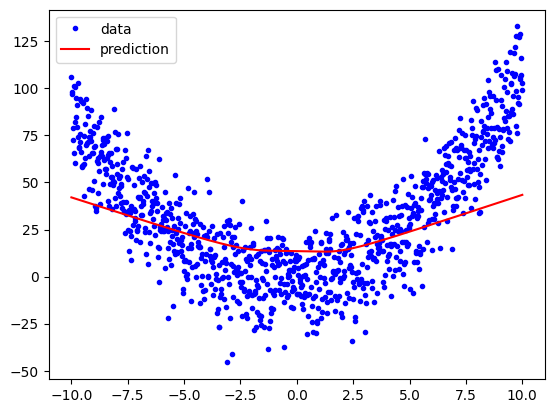

In [60]:
## The following code is an example of using a custom loss function!
import numpy as np
from matplotlib import pyplot as plt

#create the data:
X = np.linspace(-10, 10, 1000)
y = X**2 + X - 3 + 15 * np.random.randn(X.shape[0])


#create the loss
class MyLoss(keras.losses.Loss):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
    
    def call(self, y_true, y_pred):
        error = y_true - y_pred
        return tf.reduce_mean(tf.pow(tf.abs(error), 1.5), axis = -1)

model = keras.models.Sequential([
    keras.layers.Input(shape = (1,)),
    keras.layers.Dense(10, activation = 'elu'),
    keras.layers.Dense(1)
])

model.compile(optimizer = keras.optimizers.Adam(learning_rate = 0.0005), loss = MyLoss)

model.fit(X, y, epochs = 100)
y_predicted = model.predict(X)

plt.plot(X, y, 'b.', label = 'data')
plt.plot(X, y_predicted, 'r-', label = 'prediction')
plt.legend(loc = 'best')
plt.show()

## Custom Activation Functions, Initializers, Regularizers, and Constraints

You can customize activation functions, initializers, regularizers, and constraints as follows:

In [61]:
def my_softplus(z):
    return tf.math.log(tf.exp(z) + 1.0)

def my_glorot_initializer(shape, dtype = tf.float32):
    stddev = tf.sqrt(2.0 / (shape[0] + shape[1]))
    return tf.random.normal(shape, stddev = stddev, dtype = dtype)

def my_l1_regularizer(weights):
    return tf.reduce_sum(tf.abs(0.01 * weights))

def my_positive_weights(weights):
    return tf.where(weights < 0.0, tf.zeros_like(weights), weights)

In [62]:
layer = keras.layers.Dense(
    30, 
    activation = my_softplus,
    kernel_initializer = my_glorot_initializer,
    kernel_regularizer = my_l1_regularizer,
    kernel_constraint = my_positive_weights
)

If a function has hyperparameters that need to be saved along with the model, then you will want to subclass the appropriate class, such as keras.regularizers.Regularizer, keras.constrains.Constraint, keras.initializers.Initializer, or keras.layers.Layer (for any layer including activation functions). 

In [63]:
class MyL1Regularizer(keras.regularizers.Regularizer):
    def __init__(self, factor):
        self.factor = factor
    
    def __call__(self, weights):
        return tf.reduce_sum(tf.abs(self.factor * weights))
    
    def get_config(self):
        return {'factor' : self.factor}

__Note:__ You should implement the call() method for losses, layers (including activation functions), and models. You should implement the __ call __() for regularizers, initializers, and constraints.

## Custom Metrics

Losses and metrics are quite different from each other. Losses are used by gradient descent to update the models weights. Therefore, they must be differentiable, and their gradient must not be 0 everywhere. Also, it is okay if they are not easily interpretable by humans. On the other hand, metrics are designed to evaluate the model, which means that they must be easily interpretable by humans, and they can be non-differentiable or have have 0 gradients everywhere. 

__Note:__ We can use metrics and losses when creating models interchangeably.

In [8]:
model.compile(loss = 'mse', optimizer = 'nadam', metrics = [create_huber(2.0)])

For each batch during training, keras will compute the metrics and keep track of its mean since the beginning of the epoch. Most of the time, this is what we want, but sometimes we don't! <br>
For example, if we use the precision as the metrics for a binary classifier, suppose the model made five positive predictions in the first batch, four of which were correct (80% precision). Then suppose it made three positive predictions in the next batch, but they were all incorrect (0% precision). The average of these two batches would be 40%, but that is not correct! The model made a total of 8 predictions, where 4 out of 8 were correct, and the rest are wrong. This makes the precision of the model 50%, not 40$. <br>

The solution is an object that can keep track of the number of true positives and the number of false positives since the beginning of the epoch and calculate the ratio between them when requested. <br>
The keras.metrics.Precision class does this by default.

In [9]:
precision = keras.metrics.Precision()
precision([0, 1, 1, 1, 0, 1, 0, 1], [1, 1, 0, 1, 0, 1, 0, 1])

<tf.Tensor: shape=(), dtype=float32, numpy=0.8>

In [10]:
precision([0, 1, 0, 0, 1, 0, 1, 1], [1, 0, 1, 1, 0, 0, 0, 0])

<tf.Tensor: shape=(), dtype=float32, numpy=0.5>

The second call to the precision() object resulted in a 0.5 total precision. This value doesn't represent the precision of the second batch alone. Instead, it represents the total precision from all the samples seen so far. <br>
Such a metric is called a _streaming metric_ or a _stateful metric_, because it gradually updates according to the samples seen so far from batch to batch.

In [11]:
precision.result() #get the current value of the metric.

<tf.Tensor: shape=(), dtype=float32, numpy=0.5>

In [12]:
precision.variables

[<KerasVariable shape=(1,), dtype=float32, path=precision/true_positives>,
 <KerasVariable shape=(1,), dtype=float32, path=precision/false_positives>]

In [14]:
precision.reset_state() #reset the variables to 0.
precision.result() 

<tf.Tensor: shape=(), dtype=float32, numpy=0.0>

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 554us/step - loss: 1968.9977 - my_metric_31: 1968.3226 
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 536us/step - loss: 1947.1204 - my_metric_31: 1981.4025
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 476us/step - loss: 2008.9209 - my_metric_31: 2067.3916
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 454us/step - loss: 1855.6924 - my_metric_31: 1952.1571
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 459us/step - loss: 1745.4675 - my_metric_31: 1878.5856
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 447us/step - loss: 1670.2393 - my_metric_31: 1836.1526
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 468us/step - loss: 1460.7238 - my_metric_31: 1670.0239
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 420us/step - loss: 1393.5056 - my_metric_31: 1667.5834
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 400us/step - loss: 1187.1654 - my_metric_31: 1539.4718
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 432us/step - loss: 1041.0349 - my_metric_31: 1449.1821
Epoch 11/100
32/32 ━━━━━━━━━

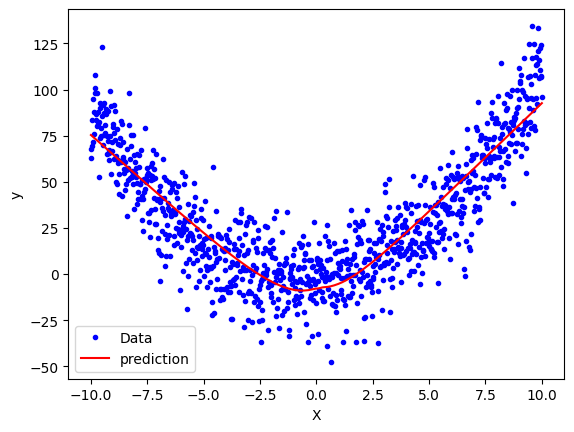

In [43]:
# Building a custom metric
import keras, tensorflow as tf
from matplotlib import pyplot as plt

class MyMetric(keras.metrics.Metric):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.total_error_seen = self.add_weight(initializer = 'zeros', name = 'total_error')
        self.total_instances_seen = self.add_weight(initializer = 'zeros', name = 'total_instances')

    def update_state(self, y_true, y_pred, sample_weight = None):
        error = tf.square(y_true - y_pred)
        self.total_error_seen.assign_add(tf.reduce_sum(error))
        self.total_instances_seen.assign_add(tf.cast(tf.size(error), tf.float32))
    
    def result(self):
        return self.total_error_seen/self.total_instances_seen
    
    
#create the data:
import numpy as np
X = np.linspace(-10, 10, 1000)
y = X**2 + X - 3 + 15 * np.random.randn(X.shape[0])

model = keras.models.Sequential([
    keras.layers.Input(shape = (1,)),
    keras.layers.Dense(100, activation = 'selu'),
    keras.layers.Dense(1)
])

model.compile(optimizer = keras.optimizers.Adam(), loss = keras.losses.MeanSquaredError, metrics = [MyMetric])

model.fit(X, y, epochs = 100, batch_size = 32)

plt.plot(X, y, 'b.', label = 'Data')
plt.plot(X, model.predict(X), 'r-', label = 'prediction')
plt.xlabel('X')
plt.ylabel('y')
plt.legend(loc = 'best')
plt.show()


## Custom Layers

Some layers don't contain weight such as keras.layers.Flatten or keras.layers.ReLU. If you want to create such a layer, you can simply wrap a python function in a lambda layer provided by keras as follows:

In [44]:
exponential_layer = keras.layers.Lambda(lambda x: tf.exp(x))

You can then use this layer a regular layer or even as an activation function. 

__Note:__ The exponential layer is sometimes used with regression models that have very different scales (e.g. 0.001, 10, 1000).

To create a layer with weights, you need to subclass the keras.layers.Layer class as follows:

In [45]:
class MyDense(keras.layers.Layer):
    def __init__(self, units, activation = None, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.activation = keras.activations.get(activation)

    def build(self, batch_input_shape):
        self.kernel = self.add_weight(
            name = 'kernel', 
            shape = [batch_input_shape[-1], self.units],
            initializer = 'glorot_normal'
        )

        self.bias = self.add_weight(
            name = 'bias',
            shape = [self.units],
            initializer = 'zeros'
        )

        super().build(batch_input_shape) #must be at the end

    def call(self, X):
        return self.activation(X @ self.kernel + self.bias)
    
    def compute_output_shape(self, batch_input_shape):
        return tf.TensorShape(batch_input_shape.as_list()[:-1] + [self.units])

    def get_config(self):
        base_config = super().get_config()
        return {**base_config, 'units' : self.units, 'activation' : keras.activations.serialize(self.activation)}


To make a layer that accepts multiple inputs and outputs multiple outputs, the call method should accept a tuple of inputs and returns a list of outputs, while the compute_output_shape() method should accept a tuple containing each input's batch shape, and it should return a list of batch output shapes (one per output).  

In [46]:
class MyMultiLayer(keras.layers.Layer):
    def call (self, X):
        X1, X2 = X
        return [X1 + X2, X1 * X2, X1 / X2]

    def compute_output_shape(self, batch_input_shape):
        b1, b2 = batch_input_shape
        return [b1, b1, b1] #assuming all batches are of the same size.

If you want your layer to behave differently during training and during testing, you should add a training argument to the call() method.

In [47]:
class MyGaussianNoise(keras.layers.Layer):
    def __init__(self, stddev, **kwargs):
        super().__init__(**kwargs)
        self.stddev = stddev
    
    def call(self, X, training = None):
        if training:
            noise = tf.random.normal(tf.shape(X), stddev = self.stddev)
            return X + noise
        else:
            return X
    
    def compute_output_shape(self, batch_input_shape):
        return batch_input_shape

## Custom Models